# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the paper in the UCI link above, the data represents 17 marketing campaigns. 

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [ ]:
%pip install imblearn

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [6]:
bank_marketing_data_df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [7]:
bank_marketing_data_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



The 'job', 'marital', 'default', 'housing', and 'loan' columns all contain missing / unknown values. To handle this, we could either set it to the most common value or drop the column entirely if it doesn't affect the output variable that much.

In general, all categorical values need to be converted to numerical values using one-hot encoding for nominal categorical columns and label encoding for ordinal columns.

With the numeric columns, depending on the distribution of the values, we might have to normalize the data to prevent any bias during training.

The plots of the features are shown below:

In [8]:
bank_marketing_data_df.keys()

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

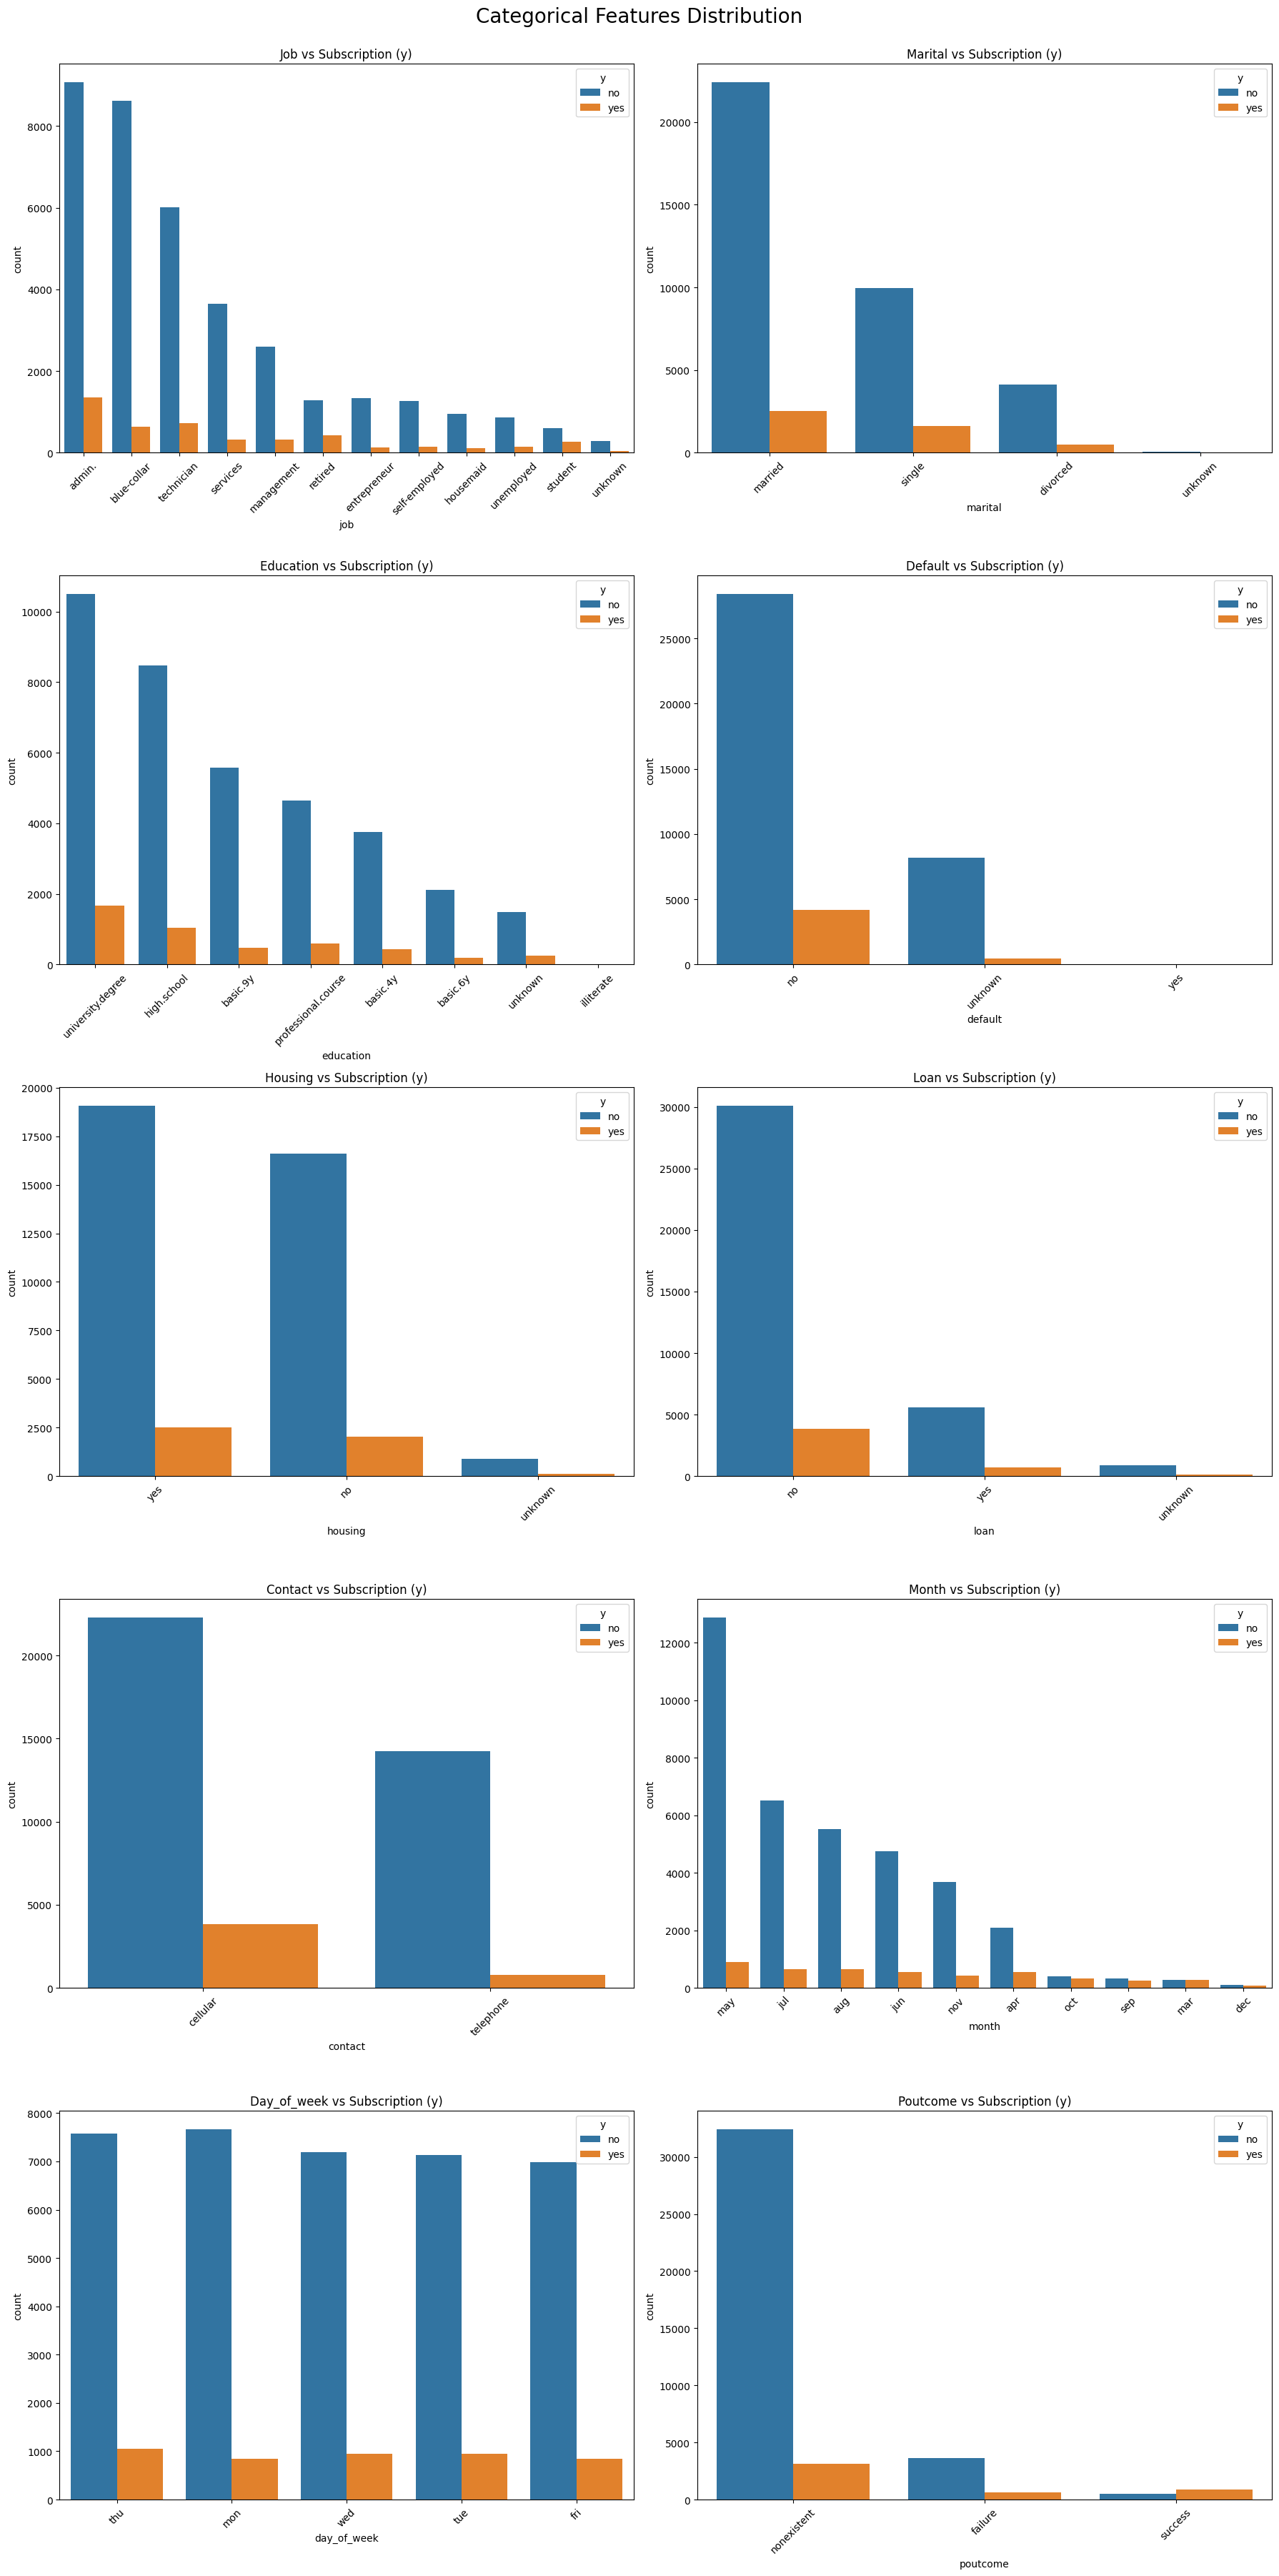

In [9]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(5, 2, figsize=(18, 36))
plt.suptitle('Categorical Features Distribution', fontsize=20, y=1)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='y', data=bank_marketing_data_df, ax=axes[i], 
                  order=bank_marketing_data_df[col].value_counts().index)
    axes[i].set_title(f'{col.capitalize()} vs Subscription (y)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

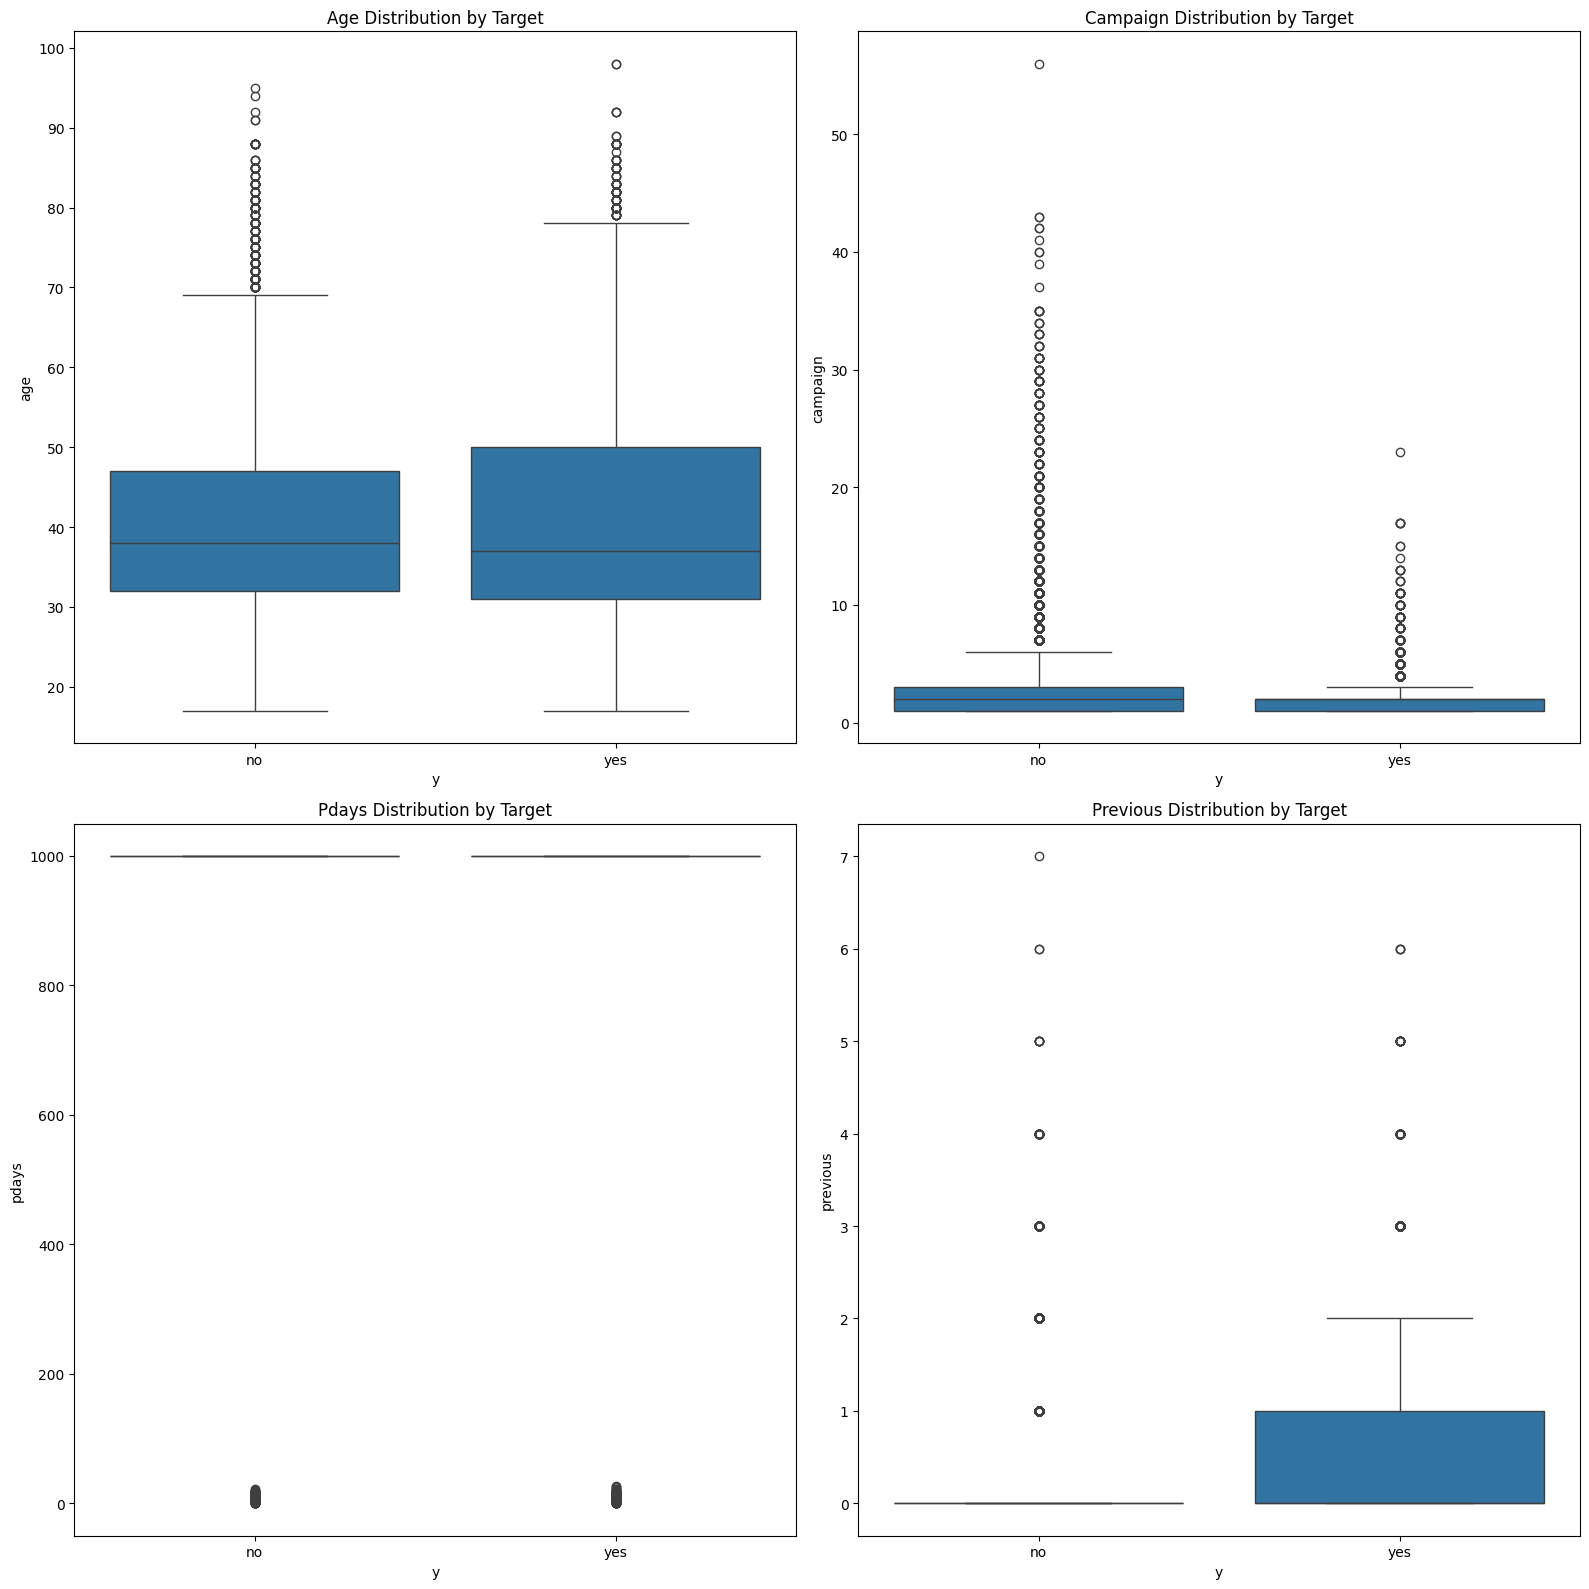

In [10]:
num_cols = ['age', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='y', y=col, data=bank_marketing_data_df, ax=axes[i])
    axes[i].set_title(f'{col.capitalize()} Distribution by Target')

if len(num_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

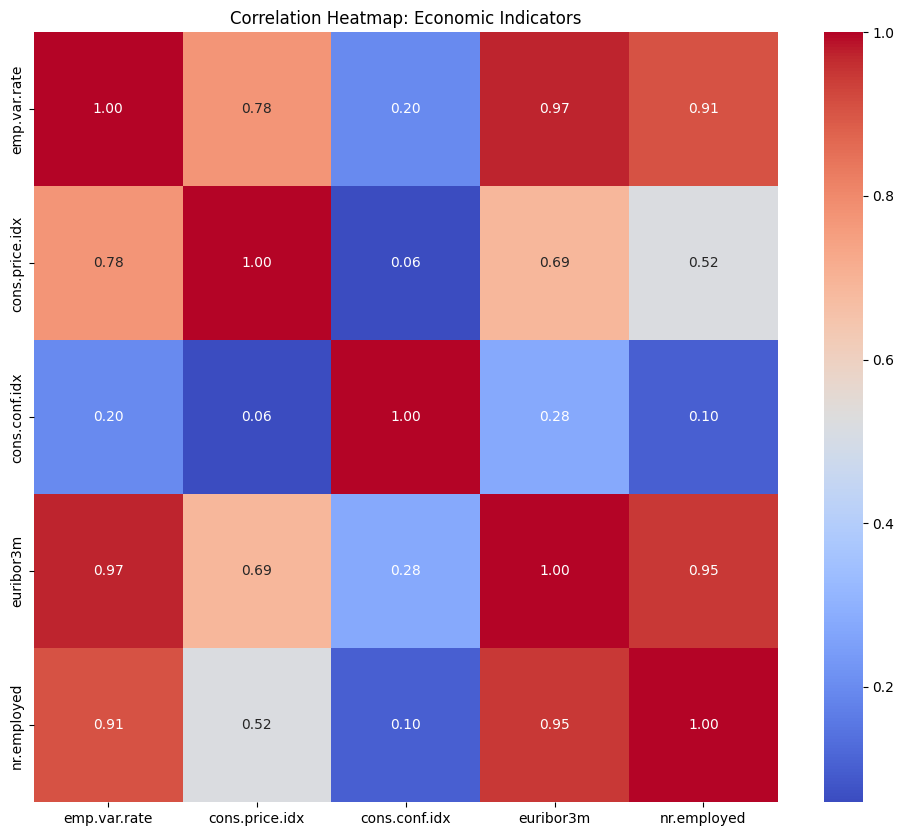

In [11]:
economic_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

plt.figure(figsize=(12, 10))
sns.heatmap(bank_marketing_data_df[economic_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Economic Indicators')
plt.show()

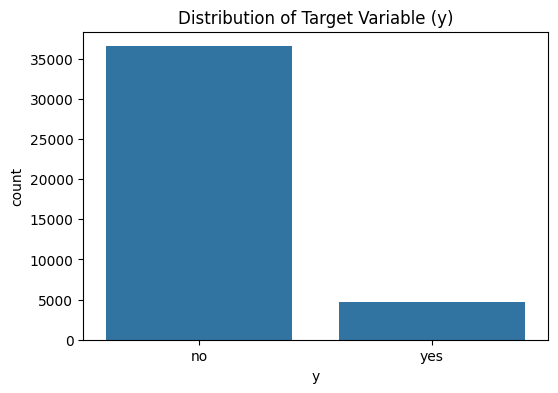

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=bank_marketing_data_df)
plt.title('Distribution of Target Variable (y)')
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [13]:
bank_marketing_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The business objective of this task is to find a model that can identify and describe the factors that contribute to the success of the call, meaning that the client ends up subscribing to the deposit. By doing this, we'd be able determine what kind of people are more likely subscribe to the deposit. Furthermore, given a client's information such as age, job, loans, education, and other factors, we should be able to predict whether the interactions with this specific client will end up in a success. In other words, we want to answer the following question: "Given a client's information, will this interaction most likely end up in a successful contact?" To do this, we will train a logistic regression model as our baseline and then train and build KNN, decision tree, and SVM models to see which model produces the best / most accurate results.

From a non-technical stand point, answering this question will help reduce the number of calls made by call centers. Based on the data, since most calls end up in a failure, knowing whether a call with a client will most likely succeed will help reduce the amount of unnecessary calls whilst keeping around the same amount of successful calls.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [14]:
# Drop unnecessary column
bank_marketing_data_df = bank_marketing_data_df.drop(columns = ['duration'])

In [15]:
# Drops rows with 'unknown' values in 'job', 'housing', and 'marital' columns
bank_marketing_data_df = bank_marketing_data_df[(bank_marketing_data_df['job'] != 'unknown')]
bank_marketing_data_df = bank_marketing_data_df[(bank_marketing_data_df['housing'] != 'unknown')]
bank_marketing_data_df = bank_marketing_data_df[(bank_marketing_data_df['marital'] != 'unknown')]
bank_marketing_data_df['default'] = bank_marketing_data_df['default'].replace('unknown', 'no')

In [16]:
# Convert categorical values to numeric values

# Convert education column
education_mapping = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
    'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 7
}
bank_marketing_data_df['education'] = bank_marketing_data_df['education'].map(education_mapping)

# Convert month column
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
bank_marketing_data_df['month'] = bank_marketing_data_df['month'].map(month_mapping)

# Convert day_of_week column
day_mapping = { 'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5 }
bank_marketing_data_df['day_of_week'] = bank_marketing_data_df['day_of_week'].map(day_mapping)

# Convert default, housing, and loan columns
binary_mapping = { 'no': 0, 'yes': 1 }
bank_marketing_data_df['default'] = bank_marketing_data_df['default'].map(binary_mapping)
bank_marketing_data_df['housing'] = bank_marketing_data_df['housing'].map(binary_mapping)
bank_marketing_data_df['loan'] = bank_marketing_data_df['loan'].map(binary_mapping)
bank_marketing_data_df['y'] = bank_marketing_data_df['y'].map(binary_mapping)

# Convert contact column
contact_mapping = { 'cellular': 0, 'telephone': 1 }
bank_marketing_data_df['contact'] = bank_marketing_data_df['contact'].map(contact_mapping)

# Convert job, marital, and poutcome columns using One-Hot Encoding
bank_marketing_data_df = pd.get_dummies(bank_marketing_data_df, columns=['job', 'marital', 'poutcome'], drop_first=True)

# Standardize the other numeric columns
numeric_columns = [ 'age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed' ]
bank_marketing_data_df[numeric_columns] = StandardScaler().fit_transform(bank_marketing_data_df[numeric_columns])

# Update pdays column

# For Decision Trees, we can keep the 999 value as is
dt_bank_marketing_data_df = bank_marketing_data_df.copy()

# Standardize and Normalize pdays column
bank_marketing_data_df['is_contacted'] = bank_marketing_data_df['pdays'].apply(lambda x: 0 if x == 999 else 1)
bank_marketing_data_df['pdays'] = bank_marketing_data_df['pdays'].replace(999, bank_marketing_data_df['pdays'].median())

standardized_bank_marketing_data_df = bank_marketing_data_df.copy()
standardized_bank_marketing_data_df['pdays'] = StandardScaler().fit_transform(standardized_bank_marketing_data_df[['pdays']])

normalized_bank_marketing_data_df = bank_marketing_data_df.copy()
normalized_bank_marketing_data_df['pdays'] = MinMaxScaler().fit_transform(normalized_bank_marketing_data_df[['pdays']])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [17]:
# Logistic Regression and SVM
lr_X_train, lr_X_test, lr_y_train, lr_y_test = train_test_split(standardized_bank_marketing_data_df.drop(columns=['y']), standardized_bank_marketing_data_df['y'], test_size=0.2, random_state=42)
svm_X_train, svm_X_test, svm_y_train, svm_y_test = train_test_split(standardized_bank_marketing_data_df.drop(columns=['y']), standardized_bank_marketing_data_df['y'], test_size=0.2, random_state=42)

In [18]:
# Decision Tree
dt_X_train, dt_X_test, dt_y_train, dt_y_test = train_test_split(dt_bank_marketing_data_df.drop(columns=['y']), dt_bank_marketing_data_df['y'], test_size=0.2, random_state=42)

In [19]:
# KNN
knn_X_train, knn_X_test, knn_y_train, knn_y_test = train_test_split(normalized_bank_marketing_data_df.drop(columns=['y']), normalized_bank_marketing_data_df['y'], test_size=0.2, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

The baseline would be a model that predicts no for every client since majority of the decisions end in a failure in the client subscribing to a term deposit. The baseline performance that our classifier should aim to beat would be around 88.7%

In [20]:
baseline_performance = bank_marketing_data_df['y'].value_counts(normalize=True).max()
baseline_performance

0.8872698037836344

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [21]:
# Start timer
lr_start_time = time.time()

# Initialize and train Logistic Regression model
lr = LogisticRegression()
lr.fit(lr_X_train, lr_y_train)
lr_train_time = time.time() - lr_start_time

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Problem 9: Score the Model

What is the accuracy of your model?

In [22]:
lr_train_preds = lr.predict(lr_X_train)
lr_test_preds = lr.predict(lr_X_test)
lr_train_accuracy = accuracy_score(lr_y_train, lr_train_preds)
lr_test_accuracy = accuracy_score(lr_y_test, lr_test_preds)
print(f"Logistic Regression Accuracy: {lr_test_accuracy:.4f}")
print("Logistic Regression Classification Report:")
print(classification_report(lr_y_test, lr_test_preds))

Logistic Regression Accuracy: 0.9014
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7075
           1       0.67      0.23      0.34       886

    accuracy                           0.90      7961
   macro avg       0.79      0.61      0.64      7961
weighted avg       0.88      0.90      0.88      7961



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [23]:
# Start timer
knn_start_time = time.time()

# Initialize and train KNN model
knn = KNeighborsClassifier()
knn.fit(knn_X_train, knn_y_train)

# Calculate training time
knn_train_time = time.time() - knn_start_time

# Make predictions and evaluate accuracy
knn_train_preds = knn.predict(knn_X_train)
knn_test_preds = knn.predict(knn_X_test)
knn_train_accuracy = accuracy_score(knn_y_train, knn_train_preds)
knn_test_accuracy = accuracy_score(knn_y_test, knn_test_preds)

In [24]:
# Start timer
dt_start_time = time.time()

# Initialize and train Decision Tree model
dt = DecisionTreeClassifier()
dt.fit(dt_X_train, dt_y_train)

# Calculate training time
dt_train_time = time.time() - dt_start_time

# Make predictions and evaluate accuracy
dt_train_preds = dt.predict(dt_X_train)
dt_test_preds = dt.predict(dt_X_test)
dt_train_accuracy = accuracy_score(dt_y_train, dt_train_preds)
dt_test_accuracy = accuracy_score(dt_y_test, dt_test_preds)

In [25]:
# Start timer
svm_start_time = time.time()

# Initialize and train SVM model
svm = SVC()
svm.fit(svm_X_train, svm_y_train)

# Calculate training time
svm_train_time = time.time() - svm_start_time

# Make predictions and evaluate accuracy
svm_train_preds = svm.predict(svm_X_train)
svm_test_preds = svm.predict(svm_X_test)
svm_train_accuracy = accuracy_score(svm_y_train, svm_train_preds)
svm_test_accuracy = accuracy_score(svm_y_test, svm_test_preds)

In [26]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Training Time (seconds)': [lr_train_time, knn_train_time, dt_train_time, svm_train_time],
    'Training Accuracy': [lr_train_accuracy, knn_train_accuracy, dt_train_accuracy, svm_train_accuracy],
    'Testing Accuracy': [lr_test_accuracy, knn_test_accuracy, dt_test_accuracy, svm_test_accuracy]
})
model_comparison

,Model,Training Time (seconds),Training Accuracy,Testing Accuracy
0,Logistic Regression,0.514518,0.899033,0.901394
1,KNN,0.015092,0.912411,0.891094
2,Decision Tree,0.120643,0.994347,0.841980
3,SVM,13.413328,0.899033,0.901771


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [132]:
# Logistic Regression Parameter Grid
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'class_weight': [None, 'balanced']
}

# Initialize and train Logistic Regression with Grid Search
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, n_jobs=-1)
lr_grid.fit(lr_X_train, lr_y_train)

# Find best parameters
lr_best_params = lr_grid.best_params_
lr_best_model = lr_grid.best_estimator_

# Predictions and evaluate accuracy
lr_grid_train_preds = lr_best_model.predict(lr_X_train)
lr_grid_test_preds = lr_best_model.predict(lr_X_test)

lr_grid_train_accuracy = accuracy_score(lr_y_train, lr_grid_train_preds)
lr_grid_test_accuracy = accuracy_score(lr_y_test, lr_grid_test_preds)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

In [166]:
# KNN Parameter Grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
}

# Initialize and train KNN with Grid Search
knn_grid = GridSearchCV(KNeighborsClassifier(n_jobs=-1), knn_param_grid, cv=5, n_jobs=-1)
knn_grid.fit(knn_X_train, knn_y_train)

# Find best parameters
knn_best_params = knn_grid.best_params_
knn_best_model = knn_grid.best_estimator_

# Predictions and evaluate accuracy
knn_grid_train_preds = knn_best_model.predict(knn_X_train)
knn_grid_test_preds = knn_best_model.predict(knn_X_test)

knn_grid_train_accuracy = accuracy_score(knn_y_train, knn_grid_train_preds)
knn_grid_test_accuracy = accuracy_score(knn_y_test, knn_grid_test_preds)

In [128]:
# Decision Tree Parameter Grid
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Initialize and train Decision Tree with Grid Search
dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5, n_jobs=-1)
dt_grid.fit(dt_X_train, dt_y_train)

# Find best parameters
dt_best_params = dt_grid.best_params_
dt_best_model = dt_grid.best_estimator_

# Predictions and evaluate accuracy
dt_grid_train_preds = dt_best_model.predict(dt_X_train)
dt_grid_test_preds = dt_best_model.predict(dt_X_test)

dt_grid_train_accuracy = accuracy_score(dt_y_train, dt_grid_train_preds)
dt_grid_test_accuracy = accuracy_score(dt_y_test, dt_grid_test_preds)

In [117]:
# SVM Parameter Grid
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Initialize and train SVM with Grid Search
svm_grid = GridSearchCV(SVC(), svm_param_grid, cv=5, n_jobs=-1)
svm_grid.fit(svm_X_train, svm_y_train)

# Find best parameters
svm_best_params = svm_grid.best_params_
svm_best_model = svm_grid.best_estimator_

# Predictions and evaluate accuracy
svm_grid_train_preds = svm_best_model.predict(svm_X_train)
svm_grid_test_preds = svm_best_model.predict(svm_X_test)

svm_grid_train_accuracy = accuracy_score(svm_y_train, svm_grid_train_preds)
svm_grid_test_accuracy = accuracy_score(svm_y_test, svm_grid_test_preds)

In [133]:
# Create model comparison with grid search results
grid_model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Best Parameters': [lr_best_params, knn_best_params, dt_best_params, svm_best_params],
    'Training Accuracy': [lr_grid_train_accuracy, knn_grid_train_accuracy, dt_grid_train_accuracy, svm_grid_train_accuracy],
    'Testing Accuracy': [lr_grid_test_accuracy, knn_grid_test_accuracy, dt_grid_test_accuracy, svm_grid_test_accuracy]
})
grid_model_comparison

,Model,Best Parameters,Training Accuracy,Testing Accuracy
0,Logistic Regression,"{'C': 0.1, 'class_weight': None, 'solver': 'lb...",0.899567,0.900892
1,KNN,"{'n_neighbors': 13, 'weights': 'uniform'}",0.905220,0.900138
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.912160,0.894486
3,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.899033,0.901771


### Applying SMOTE

In [144]:
smote = SMOTE(sampling_strategy=0.25)
smote_standardized_X, smote_standardized_y = smote.fit_resample(standardized_bank_marketing_data_df.drop(columns=['y']), standardized_bank_marketing_data_df['y'])
smote_dt_X, smote_dt_y = smote.fit_resample(dt_bank_marketing_data_df.drop(columns=['y']), dt_bank_marketing_data_df['y'])
smote_knn_X, smote_knn_y = smote.fit_resample(normalized_bank_marketing_data_df.drop(columns=['y']), normalized_bank_marketing_data_df['y'])

# Logistic Regression and SVM
smote_lr_X_train, smote_lr_X_test, smote_lr_y_train, smote_lr_y_test = train_test_split(smote_standardized_X, smote_standardized_y, test_size=0.2, random_state=42)
smote_svm_X_train, smote_svm_X_test, smote_svm_y_train, smote_svm_y_test = train_test_split(smote_standardized_X, smote_standardized_y, test_size=0.2, random_state=42)

# Decision Tree
smote_dt_X_train, smote_dt_X_test, smote_dt_y_train, smote_dt_y_test = train_test_split(smote_dt_X, smote_dt_y, test_size=0.2, random_state=42)

# KNN
smote_knn_X_train, smote_knn_X_test, smote_knn_y_train, smote_knn_y_test = train_test_split(smote_knn_X, smote_knn_y, test_size=0.2, random_state=42)

In [146]:
# Initialize and train Logistic Regression with Grid Search
smote_lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, n_jobs=-1)
smote_lr_grid.fit(smote_lr_X_train, smote_lr_y_train)

# Find best parameters
smote_lr_best_params = smote_lr_grid.best_params_
smote_lr_best_model = smote_lr_grid.best_estimator_

# Predictions and evaluate accuracy
smote_lr_grid_train_preds = smote_lr_best_model.predict(smote_lr_X_train)
smote_lr_grid_test_preds = smote_lr_best_model.predict(smote_lr_X_test)

smote_lr_grid_train_accuracy = accuracy_score(smote_lr_y_train, smote_lr_grid_train_preds)
smote_lr_grid_test_accuracy = accuracy_score(smote_lr_y_test, smote_lr_grid_test_preds)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

In [150]:
# Initialize and train KNN with Grid Search
smote_knn_grid = GridSearchCV(KNeighborsClassifier(n_jobs=-1), knn_param_grid, cv=5, n_jobs=-1)
smote_knn_grid.fit(smote_knn_X_train, smote_knn_y_train)

# Find best parameters
smote_knn_best_params = smote_knn_grid.best_params_
smote_knn_best_model = smote_knn_grid.best_estimator_

# Predictions and evaluate accuracy
smote_knn_grid_train_preds = smote_knn_best_model.predict(smote_knn_X_train)
smote_knn_grid_test_preds = smote_knn_best_model.predict(smote_knn_X_test)

smote_knn_grid_train_accuracy = accuracy_score(smote_knn_y_train, smote_knn_grid_train_preds)
smote_knn_grid_test_accuracy = accuracy_score(smote_knn_y_test, smote_knn_grid_test_preds)

In [148]:
# Initialize and train Logistic Regression with Grid Search
smote_dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5, n_jobs=-1)
smote_dt_grid.fit(smote_dt_X_train, smote_dt_y_train)

# Find best parameters
smote_dt_best_params = smote_dt_grid.best_params_
smote_dt_best_model = smote_dt_grid.best_estimator_

# Predictions and evaluate accuracy
smote_dt_grid_train_preds = smote_dt_best_model.predict(smote_dt_X_train)
smote_dt_grid_test_preds = smote_dt_best_model.predict(smote_dt_X_test)

smote_dt_grid_train_accuracy = accuracy_score(smote_dt_y_train, smote_dt_grid_train_preds)
smote_dt_grid_test_accuracy = accuracy_score(smote_dt_y_test, smote_dt_grid_test_preds)

In [151]:
# SVM Parameter Grid
smote_svm_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Initialize and train SVM with Grid Search
smote_svm_grid = GridSearchCV(SVC(), smote_svm_param_grid, cv=5, n_jobs=-1)
smote_svm_grid.fit(smote_svm_X_train, smote_svm_y_train)

# Find best parameters
smote_svm_best_params = smote_svm_grid.best_params_
smote_svm_best_model = smote_svm_grid.best_estimator_

# Predictions and evaluate accuracy
smote_svm_grid_train_preds = smote_svm_best_model.predict(smote_svm_X_train)
smote_svm_grid_test_preds = smote_svm_best_model.predict(smote_svm_X_test)

smote_svm_grid_train_accuracy = accuracy_score(smote_svm_y_train, smote_svm_grid_train_preds)
smote_svm_grid_test_accuracy = accuracy_score(smote_svm_y_test, smote_svm_grid_test_preds)

In [152]:
# Create model comparison with grid search results with SMOTE data
smote_grid_model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Best Parameters': [smote_lr_best_params, smote_knn_best_params, smote_dt_best_params, smote_svm_best_params],
    'Training Accuracy': [smote_lr_grid_train_accuracy, smote_knn_grid_train_accuracy, smote_dt_grid_train_accuracy, smote_svm_grid_train_accuracy],
    'Testing Accuracy': [smote_lr_grid_test_accuracy, smote_knn_grid_test_accuracy, smote_dt_grid_test_accuracy, smote_svm_grid_test_accuracy]
})
smote_grid_model_comparison

,Model,Best Parameters,Training Accuracy,Testing Accuracy
0,Logistic Regression,"{'C': 0.01, 'class_weight': None, 'solver': 'l...",0.848171,0.847208
1,KNN,"{'n_neighbors': 13, 'weights': 'distance'}",0.995243,0.860347
2,Decision Tree,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.887700,0.873372
3,SVM,"{'C': 10, 'gamma': 'auto'}",0.872806,0.861819


In [168]:
lr_classification_report = classification_report(lr_y_test, lr_grid_test_preds)
smote_lr_classification_report = classification_report(smote_lr_y_test, smote_lr_grid_test_preds)

print('Without SMOTE')
print(lr_classification_report)

print('With SMOTE')
print(smote_lr_classification_report)

Without SMOTE
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7075
           1       0.67      0.22      0.33       886

    accuracy                           0.90      7961
   macro avg       0.79      0.60      0.64      7961
weighted avg       0.88      0.90      0.88      7961

With SMOTE
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      7060
           1       0.72      0.39      0.51      1769

    accuracy                           0.85      8829
   macro avg       0.79      0.68      0.71      8829
weighted avg       0.83      0.85      0.83      8829



In [169]:
knn_classification_report = classification_report(knn_y_test, knn_grid_test_preds)
smote_knn_classification_report = classification_report(smote_knn_y_test, smote_knn_grid_test_preds)

print('Without SMOTE')
print(knn_classification_report)

print('With SMOTE')
print(smote_knn_classification_report)

Without SMOTE
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7075
           1       0.62      0.27      0.38       886

    accuracy                           0.90      7961
   macro avg       0.77      0.62      0.66      7961
weighted avg       0.88      0.90      0.88      7961

With SMOTE
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      7060
           1       0.68      0.58      0.62      1769

    accuracy                           0.86      8829
   macro avg       0.79      0.76      0.77      8829
weighted avg       0.85      0.86      0.86      8829



In [170]:
dt_classification_report = classification_report(dt_y_test, dt_grid_test_preds)
smote_dt_classification_report = classification_report(smote_dt_y_test, smote_dt_grid_test_preds)

print('Without SMOTE')
print(dt_classification_report)

print('With SMOTE')
print(smote_dt_classification_report)

Without SMOTE
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7075
           1       0.56      0.24      0.34       886

    accuracy                           0.89      7961
   macro avg       0.74      0.61      0.64      7961
weighted avg       0.87      0.89      0.88      7961

With SMOTE
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7060
           1       0.77      0.53      0.63      1769

    accuracy                           0.87      8829
   macro avg       0.83      0.75      0.78      8829
weighted avg       0.87      0.87      0.86      8829



In [171]:
svm_classification_report = classification_report(svm_y_test, svm_grid_test_preds)
smote_svm_classification_report = classification_report(smote_svm_y_test, smote_svm_grid_test_preds)

print('Without SMOTE')
print(svm_classification_report)

print('With SMOTE')
print(smote_svm_classification_report)

Without SMOTE
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7075
           1       0.72      0.19      0.30       886

    accuracy                           0.90      7961
   macro avg       0.82      0.59      0.62      7961
weighted avg       0.89      0.90      0.88      7961

With SMOTE
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7060
           1       0.74      0.48      0.58      1769

    accuracy                           0.86      8829
   macro avg       0.81      0.72      0.75      8829
weighted avg       0.85      0.86      0.85      8829

